# Gradient Descent: Lost Hiker Story

### Goal:
Understand how machines "learn" by minimizing loss using Gradient Descent


* Model = Hiker  



* Loss Function = Mountain  
* Minimum = Treasure  
* Gradient = Slope  


Let’s guide the hiker to the treasure!

In [ ]:
# STORY MODE: Lost Hiker Optimization Game

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("A lost hiker is on a mountain...")
print("Treasure is at the lowest point (minimum loss)")
print("Goal: Reach the treasure using 'smart steps' (Gradient Descent)")
print("\nYour job: Guide the hiker!")

A lost hiker is on a mountain...
Treasure is at the lowest point (minimum loss)
Goal: Reach the treasure using 'smart steps' (Gradient Descent)

Your job: Guide the hiker!


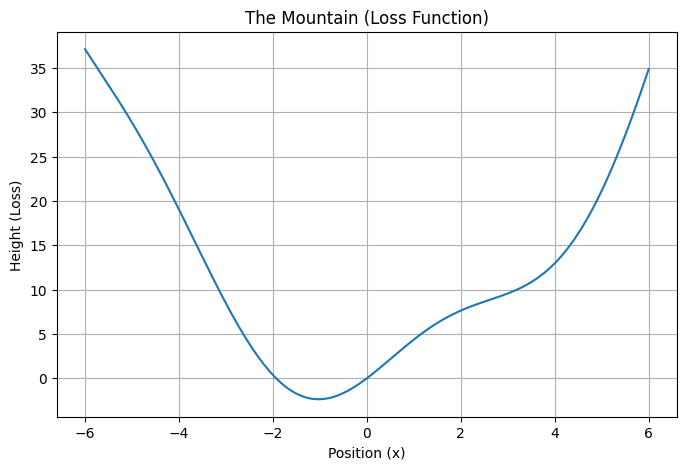

In [ ]:
# Define a simple mountain (loss function)

def loss(x):
    return x**2 + 4*np.sin(x)

def gradient(x):
    return 2*x + 4*np.cos(x)

# Visualize
x_vals = np.linspace(-6, 6, 200)
y_vals = loss(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals)
plt.title("The Mountain (Loss Function)")
plt.xlabel("Position (x)")
plt.ylabel("Height (Loss)")
plt.grid()
plt.show()

In [ ]:
# Try ONE step manually

x = 5  # starting point
lr = 0.1

print(f"Starting at x = {x}")
print(f"Loss = {loss(x):.2f}")

grad = gradient(x)
print(f"Gradient (slope) = {grad:.2f}")

# Key idea
new_x = x - lr * grad

print("\nAfter ONE step:")
print(f"New x = {new_x:.2f}")
print(f"New Loss = {loss(new_x):.2f}")

Starting at x = 5
Loss = 21.16
Gradient (slope) = 11.13

After ONE step:
New x = 3.89
New Loss = 12.39


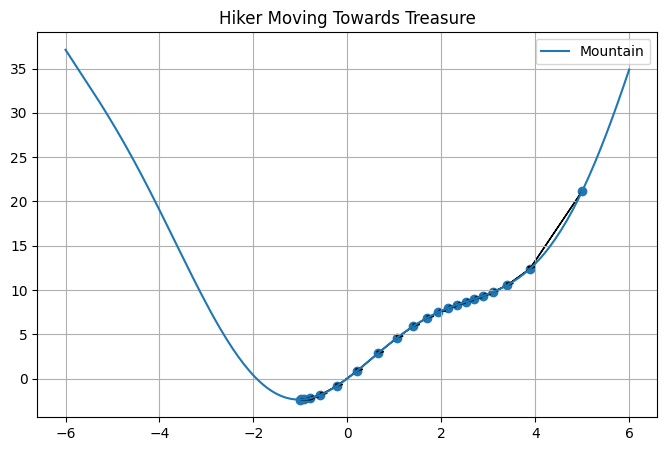

In [ ]:
# Gradient Descent Simulation

x = 5
lr = 0.1
steps = 20

path = [x]

for _ in range(steps):
    x = x - lr * gradient(x)
    path.append(x)

# Plot
x_vals = np.linspace(-6, 6, 200)
plt.figure(figsize=(8,5))
plt.plot(x_vals, loss(x_vals), label="Mountain")

# Path points
plt.scatter(path, [loss(p) for p in path])

# Arrows (movement)
for i in range(len(path)-1):
    plt.arrow(path[i], loss(path[i]),
              path[i+1]-path[i],
              loss(path[i+1]) - loss(path[i]),
              head_width=0.15, length_includes_head=True)

plt.title("Hiker Moving Towards Treasure")
plt.legend()
plt.grid()
plt.show()

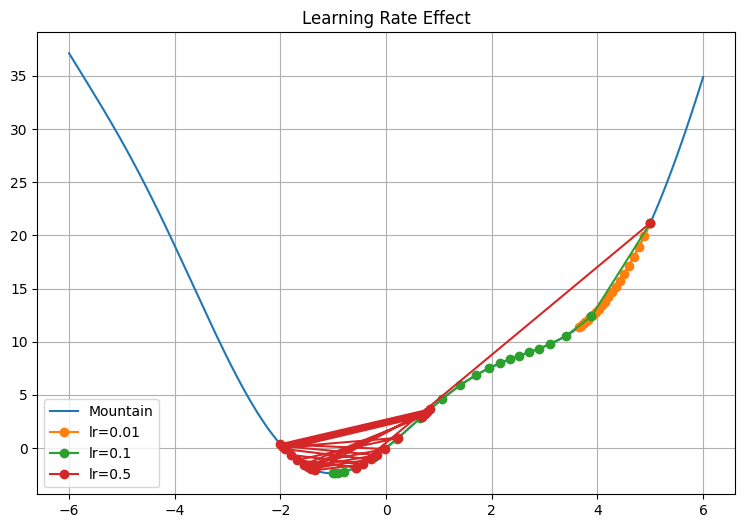

In [ ]:
# Learning Rate Comparison

lrs = [0.01, 0.1, 0.5]

plt.figure(figsize=(9,6))
x_vals = np.linspace(-6, 6, 200)
plt.plot(x_vals, loss(x_vals), label="Mountain")

for lr in lrs:
    x = 5
    path = [x]

    for _ in range(20):
        x = x - lr * gradient(x)
        path.append(x)

    plt.plot(path, [loss(p) for p in path], marker='o', label=f"lr={lr}")

plt.legend()
plt.title("Learning Rate Effect")
plt.grid()
plt.show()

In [ ]:
# Simple dataset

X = np.array([1, 2, 3, 4])
y = np.array([3, 5, 7, 9])  # y ≈ 2x + 1

# Initialize
w, b = 0.0, 0.0
lr = 0.1

def predict(x, w, b):
    return w*x + b

def compute_loss(w, b):
    return np.mean((y - predict(X, w, b))**2) # MSE instead of SSE
# y : actual outcome
# grad of grad(np.mean((y - (w*x + b))**2))?

def gradients(w, b):
    dw = -2*np.mean(X*(y - predict(X, w, b))) # grad of loss function d(loss)/dw
    db = -2*np.mean(y - predict(X, w, b))
    return dw, db

# Training
losses = []

for i in range(20): # while loop
    dw, db = gradients(w, b)
    w -= lr * dw
    b -= lr * db

    l = compute_loss(w, b)
    # if l<=1 break
    losses.append(l)

    print(f"Step {i:02d}: w={w:.2f}, b={b:.2f}, loss={l:.2f}")

Step 00: w=3.50, b=1.20, loss=18.41
Step 01: w=1.15, b=0.41, loss=8.27
Step 02: w=2.72, b=0.95, loss=3.72
Step 03: w=1.66, b=0.60, loss=1.68
Step 04: w=2.37, b=0.85, loss=0.76
Step 05: w=1.89, b=0.70, loss=0.35
Step 06: w=2.21, b=0.81, loss=0.16
Step 07: w=1.99, b=0.75, loss=0.08
Step 08: w=2.13, b=0.80, loss=0.04
Step 09: w=2.03, b=0.78, loss=0.02
Step 10: w=2.10, b=0.80, loss=0.01
Step 11: w=2.05, b=0.80, loss=0.01
Step 12: w=2.08, b=0.81, loss=0.01
Step 13: w=2.06, b=0.81, loss=0.01
Step 14: w=2.07, b=0.82, loss=0.01
Step 15: w=2.06, b=0.82, loss=0.01
Step 16: w=2.06, b=0.83, loss=0.00
Step 17: w=2.05, b=0.83, loss=0.00
Step 18: w=2.06, b=0.84, loss=0.00
Step 19: w=2.05, b=0.84, loss=0.00


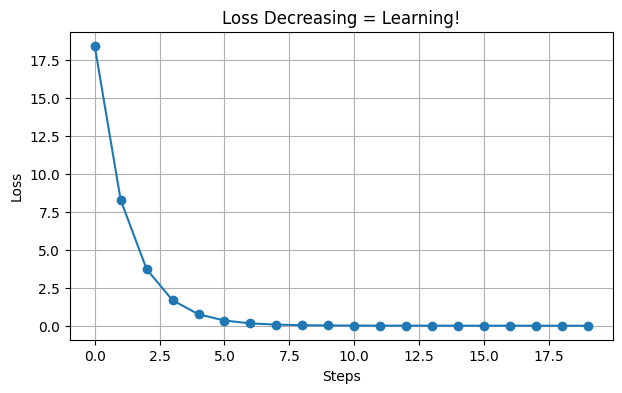

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(losses, marker='o')
plt.title("Loss Decreasing = Learning!")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.grid()
plt.show()

# Key Takeaways

- Gradient = direction of steepest increase  
- We move in the **opposite direction**  
- Learning rate controls step size  
- Too small → slow  
- Too large → unstable  


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# Build model
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

model.fit(x_train, y_train, epochs=3)

**Question:** Construct a CNN with the following specifications:

* Input: 28×28×1

* Conv Layer 1: 16 filters, 3×3, ReLU

* MaxPooling: 2×2

* Conv Layer 2: 32 filters, 3×3, ReLU

* MaxPooling: 2×2

* Flatten

* Dense: 64 neurons, ReLU

* Output: 10 neurons (classification)

**Tasks:**

* Implement the model

* Print model summary

* Train for 3 epochs on MNIST

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ----------------------------
# 1. Load and preprocess data
# ----------------------------

transform = transforms.Compose([
    transforms.ToTensor(),          # converts to [0,1] and shape (1,28,28)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ----------------------------
# 2. Define model
# ----------------------------

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)   # (28x28 → 26x26)
        self.pool  = nn.MaxPool2d(2, 2)                # halve size

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)  # (13x13 → 11x11)

        self.fc1 = nn.Linear(32 * 5 * 5, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16,13,13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,5,5)

        x = x.view(-1, 32 * 5 * 5)                 # flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)                            # no softmax here

        return x

model = CNN()

# ----------------------------
# 3. Loss and optimizer
# ----------------------------

criterion = nn.CrossEntropyLoss()   # includes softmax internally
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ----------------------------
# 4. Training loop
# ----------------------------

epochs = 3

for epoch in range(epochs):
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward() # calc gradients
        optimizer.step() # 1 GD step (x-lr*grad)

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# ----------------------------
# 5. Evaluation
# ----------------------------

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", correct / total)

100%|██████████| 9.91M/9.91M [00:00<00:00, 61.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


Epoch 1, Loss: 247.4707
Epoch 2, Loss: 67.3668
Epoch 3, Loss: 48.6579
Test Accuracy: 0.9871
